# ***`Final Results`***
---
---
***Models:***
- Mistral
- LLama
- GPT-4o

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None) # display all columns

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv('../data/original_data/newsroom_judged.csv')

columns_to_keep = [
    # Human Judgements
    'informativeness_scores', 'relevance_scores', 'fluency_scores', 'coherence_scores',
    # GPT
    'GPT_informativeness_as_a_judge', 'GPT_relevance_as_a_judge',
    'GPT_fluency_as_a_judge', 'GPT_coherence_as_a_judge',
    # LLAMA
    'LLAMA_informativeness_as_a_judge', 'LLAMA_relevance_as_a_judge',
    'LLAMA_fluency_as_a_judge', 'LLAMA_coherence_as_a_judge',
    # MISTRAL
    'MISTRAL_informativeness_as_a_judge', 'MISTRAL_relevance_as_a_judge',
    'MISTRAL_fluency_as_a_judge', 'MISTRAL_coherence_as_a_judge'
]

df = df.loc[:, columns_to_keep]
print(df.shape)
df.head()

(420, 16)


,informativeness_scores,relevance_scores,fluency_scores,coherence_scores,GPT_informativeness_as_a_judge,GPT_relevance_as_a_judge,GPT_fluency_as_a_judge,GPT_coherence_as_a_judge,LLAMA_informativeness_as_a_judge,LLAMA_relevance_as_a_judge,LLAMA_fluency_as_a_judge,LLAMA_coherence_as_a_judge,MISTRAL_informativeness_as_a_judge,MISTRAL_relevance_as_a_judge,MISTRAL_fluency_as_a_judge,MISTRAL_coherence_as_a_judge
0,"[4, 3, 1]","[4, 5, 1]","[3, 5, 3]","[4, 4, 3]",Evaluation Error,Evaluation Error,Evaluation Error,Evaluation Error,1,1,1,1,1 (low),1 (low),1 (low),1
1,"[4, 5, 4]","[4, 5, 5]","[3, 5, 5]","[3, 5, 4]",Evaluation Error,Evaluation Error,Evaluation Error,Evaluation Error,4,5,4,4,4.5,5,5,5
2,"[3, 5, 4]","[4, 5, 3]","[4, 5, 3]","[4, 5, 4]",Evaluation Error,Evaluation Error,Evaluation Error,Evaluation Error,3,4,4,4,3.5 (The summary captures the main points of t...,4.5 (The summary is very consistent with the d...,5 (high),4.5 (The summary is concise and accurately rep...
3,"[3, 3, 3]","[3, 4, 4]","[3, 2, 4]","[3, 2, 3]",Evaluation Error,Evaluation Error,Evaluation Error,Evaluation Error,1,2,2,2,2,3,2,2
4,"[3, 4, 5]","[4, 3, 3]","[4, 3, 4]","[3, 4, 4]",Evaluation Error,Evaluation Error,Evaluation Error,Evaluation Error,1,1,1,1,2,3,1 (low) - The summary is incomplete and lacks ...,1


- cast human scores to list & check whethjer allways 3 judges present

In [3]:
import ast

human_scores = [col for col in df.columns if 'scores' in col]


# Safely evaluate only if it's a string
for col in human_scores:
    df[col] = df[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# allways three judges?
for col in human_scores:
    lengths = df[col].apply(len)

    # See value counts of list lengths
    print(lengths.value_counts())

    # Check if all lists have the same length
    all_same_length = lengths.nunique() == 1
    print(f"All lists same length? {all_same_length}")
    print()


informativeness_scores
3    420
Name: count, dtype: int64
All lists same length? True

relevance_scores
3    420
Name: count, dtype: int64
All lists same length? True

fluency_scores
3    420
Name: count, dtype: int64
All lists same length? True

coherence_scores
3    420
Name: count, dtype: int64
All lists same length? True



- break up human judgements into columns (human_#1,...,human_#3)

In [4]:
# break up human judgements into columns (human_#1,...,human_#3)
for col in human_scores:
    metric_name = col.split('_')[0]
    for i in range(1, 4):
        new_col_name = f'{metric_name}_human_#{i}'
        df[new_col_name] = df[col].apply(lambda x: x[i-1])

df.drop(columns=human_scores, inplace=True)

df.head(3)

,GPT_informativeness_as_a_judge,GPT_relevance_as_a_judge,GPT_fluency_as_a_judge,GPT_coherence_as_a_judge,LLAMA_informativeness_as_a_judge,LLAMA_relevance_as_a_judge,LLAMA_fluency_as_a_judge,LLAMA_coherence_as_a_judge,MISTRAL_informativeness_as_a_judge,MISTRAL_relevance_as_a_judge,MISTRAL_fluency_as_a_judge,MISTRAL_coherence_as_a_judge,informativeness_human_#1,informativeness_human_#2,informativeness_human_#3,relevance_human_#1,relevance_human_#2,relevance_human_#3,fluency_human_#1,fluency_human_#2,fluency_human_#3,coherence_human_#1,coherence_human_#2,coherence_human_#3
0,Evaluation Error,Evaluation Error,Evaluation Error,Evaluation Error,1,1,1,1,1 (low),1 (low),1 (low),1,4,3,1,4,5,1,3,5,3,4,4,3
1,Evaluation Error,Evaluation Error,Evaluation Error,Evaluation Error,4,5,4,4,4.5,5,5,5,4,5,4,4,5,5,3,5,5,3,5,4
2,Evaluation Error,Evaluation Error,Evaluation Error,Evaluation Error,3,4,4,4,3.5 (The summary captures the main points of t...,4.5 (The summary is very consistent with the d...,5 (high),4.5 (The summary is concise and accurately rep...,3,5,4,4,5,3,4,5,3,4,5,4


- Human judge range:

In [5]:
df['informativeness_human_#3'].value_counts()

informativeness_human_#3
4    149
3    111
5     65
1     51
2     44
Name: count, dtype: int64

- inspect textual model outputs containing the actual scores

In [6]:
import random

COLUMN = 'MISTRAL_coherence_as_a_judge'

n_random_numbers = 9

random_numbers = [random.randint(0, len(df)) for _ in range(n_random_numbers)]

#display outouts and inspect
for i in random_numbers:
    print(df[COLUMN].iloc[i])
    print()


1 (low)

1 (low)

4.5 (The summary is mostly coherent and makes sense, but it could be improved by including more context about the controversy and the professor's defense of his site.)

1 (low)

1

4

1 (low)

4

3



- extract numerical scores from llm outputs:

In [7]:
import re

def extract_valid_rating(series: pd.Series) -> pd.Series:
    """
    Extract leading number from strings in a Series,
    keeping only values between 1 and 5 inclusive.
    Non-matching or out-of-range values are returned as NaN.

    Parameters
    ----------
    series : pd.Series

    Returns
    -------
    pd.Series
        Series of integers in [0, 6] or NaN.
    """
    # Pattern matches optional whitespace + number with optional decimal part
    pattern = re.compile(r'^\s*(\d+(?:\.\d+)?)')

    values = []
    for item in series:
        text = str(item)
        match = pattern.match(text)
        if match:
            value = float(match.group(1))
            if 1 <= value <= 5:
                values.append(value)
            else:
                values.append(np.nan)
        else:
            values.append(np.nan)

    return pd.Series(values, index=series.index)




model_columns = [col for col in df.columns if 'as_a_judge' in col]

# Drop rows where any model column contains 'Evaluation Error'
mask = df[model_columns].apply(lambda row: row.astype(str).str.contains("Evaluation Error")).any(axis=1)
df = df[~mask]


# drop nan and inf:
df =df.dropna()

for col in model_columns:
    df[col] = extract_valid_rating(df[col])
    #round and convert to int
    df[col] = df[col].round().astype("Int64")


df.head(3)

,GPT_informativeness_as_a_judge,GPT_relevance_as_a_judge,GPT_fluency_as_a_judge,GPT_coherence_as_a_judge,LLAMA_informativeness_as_a_judge,LLAMA_relevance_as_a_judge,LLAMA_fluency_as_a_judge,LLAMA_coherence_as_a_judge,MISTRAL_informativeness_as_a_judge,MISTRAL_relevance_as_a_judge,MISTRAL_fluency_as_a_judge,MISTRAL_coherence_as_a_judge,informativeness_human_#1,informativeness_human_#2,informativeness_human_#3,relevance_human_#1,relevance_human_#2,relevance_human_#3,fluency_human_#1,fluency_human_#2,fluency_human_#3,coherence_human_#1,coherence_human_#2,coherence_human_#3
7,1,1,1,1,2,2,1,2,4,1,2,1,3,1,1,4,1,1,5,3,1,5,1,1
8,1,1,1,1,2,2,2,3,4,3,4,3,3,1,4,4,2,3,4,3,3,4,1,4
9,1,1,2,1,2,2,2,2,5,5,4,4,2,1,5,2,5,4,3,5,5,2,2,5


- Range of judge ratings:

In [8]:
df.isnull().sum()

GPT_informativeness_as_a_judge        0
GPT_relevance_as_a_judge              0
GPT_fluency_as_a_judge                0
GPT_coherence_as_a_judge              0
LLAMA_informativeness_as_a_judge      0
LLAMA_relevance_as_a_judge            0
LLAMA_fluency_as_a_judge              0
LLAMA_coherence_as_a_judge            0
MISTRAL_informativeness_as_a_judge    4
MISTRAL_relevance_as_a_judge          4
MISTRAL_fluency_as_a_judge            0
MISTRAL_coherence_as_a_judge          0
informativeness_human_#1              0
informativeness_human_#2              0
informativeness_human_#3              0
relevance_human_#1                    0
relevance_human_#2                    0
relevance_human_#3                    0
fluency_human_#1                      0
fluency_human_#2                      0
fluency_human_#3                      0
coherence_human_#1                    0
coherence_human_#2                    0
coherence_human_#3                    0
dtype: int64

## ***`Diversity of Opinion`***
---

In [9]:
# Fix import path - add parent directory to Python path
import sys
import os
sys.path.append(os.path.join(os.getcwd(), '..', '..'))

from llm_good_enough import LLMGoodEnough

human_informative_cols = [col for col in df.columns if 'informativeness_human_' in col]
human_relevance_cols   = [col for col in df.columns if 'relevance_human_' in col]
human_fluency_cols      = [col for col in df.columns if 'fluency_human_' in col]
human_coherence_cols   = [col for col in df.columns if 'coherence_human_' in col]

MIN, MAX = 1, 5

Informativeness_LLM_Evaluator = LLMGoodEnough(df=df, human_cols=human_informative_cols, min_score=MIN, max_score=MAX)
Relevance_LLM_Evaluator       = LLMGoodEnough(df=df, human_cols=human_relevance_cols, min_score=MIN, max_score=MAX)
Fluency_LLM_Evaluator         = LLMGoodEnough(df=df, human_cols=human_fluency_cols, min_score=MIN, max_score=MAX)
Coherence_LLM_Evaluator       = LLMGoodEnough(df=df, human_cols=human_coherence_cols, min_score=MIN, max_score=MAX)

### ***1. Human-Human Disagreement***


In [10]:
human_disagreements = {
    'informativeness': Informativeness_LLM_Evaluator.compute_human_disagreements(),
    'relevance': Relevance_LLM_Evaluator.compute_human_disagreements(),
    'fluency': Fluency_LLM_Evaluator.compute_human_disagreements(),
    'coherence': Coherence_LLM_Evaluator.compute_human_disagreements()
}

# print mean and std for each array in human_disagreements
for metric, disagreements in human_disagreements.items():
    print(f"{metric}: mean={disagreements.mean():.2f}, std={disagreements.std():.2f}")

informativeness: mean=1.05, std=0.95
relevance: mean=1.15, std=1.05
fluency: mean=1.45, std=1.11
coherence: mean=1.32, std=1.07


In [11]:
human_disagreements_df = pd.DataFrame(human_disagreements)
print(human_disagreements_df.shape)
human_disagreements_df.head()

(981, 4)


,informativeness,relevance,fluency,coherence
0,2,3,2,4
1,2,2,1,3
2,1,3,2,0
3,3,0,1,1
4,2,2,3,3


### ***2. Human-LLM Disagreement***

In [12]:
evaluators = {
    'informativeness_evaluator': Informativeness_LLM_Evaluator,
    'relevance_evaluator': Relevance_LLM_Evaluator,
    'fluency_evaluator': Fluency_LLM_Evaluator,
    'coherence_evaluator': Coherence_LLM_Evaluator
}

# as dict comprehension
llm_human_disagreements = {
    f'{model}_{metric}': evaluators[f'{metric}_evaluator'].compute_llm_human_disagreements(
        f'{model}_{metric}_as_a_judge'
    )
    for model in ['MISTRAL', 'LLAMA', 'GPT']
    for metric in ['informativeness', 'relevance', 'fluency', 'coherence']
}

# print mean and std for each array in llm_human_disagreements
for metric, disagreements in llm_human_disagreements.items():
    print(f"{metric}: mean={disagreements.mean():.2f}, std={disagreements.std():.2f}")

❌ Data contains NaN values in MISTRAL_informativeness_as_a_judge column.
✅Dropping 4 rows with nan in MISTRAL_informativeness_as_a_judge column.
❌ Data contains NaN values in MISTRAL_relevance_as_a_judge column.
✅Dropping 4 rows with nan in MISTRAL_relevance_as_a_judge column.
MISTRAL_informativeness: mean=0.99, std=1.00
MISTRAL_relevance: mean=1.02, std=1.03
MISTRAL_fluency: mean=1.26, std=1.15
MISTRAL_coherence: mean=1.24, std=1.10
LLAMA_informativeness: mean=1.57, std=1.05
LLAMA_relevance: mean=1.61, std=1.13
LLAMA_fluency: mean=1.48, std=1.19
LLAMA_coherence: mean=1.31, std=1.03
GPT_informativeness: mean=1.74, std=1.09
GPT_relevance: mean=1.61, std=1.21
GPT_fluency: mean=1.48, std=1.22
GPT_coherence: mean=1.68, std=1.22


In [13]:
llm_human_disagreements.keys()

dict_keys(['MISTRAL_informativeness', 'MISTRAL_relevance', 'MISTRAL_fluency', 'MISTRAL_coherence', 'LLAMA_informativeness', 'LLAMA_relevance', 'LLAMA_fluency', 'LLAMA_coherence', 'GPT_informativeness', 'GPT_relevance', 'GPT_fluency', 'GPT_coherence'])

### 3. ***Human-Random Judge Disagreement***


In [14]:
# compute human-random judge disagreement
human_random_disagreements = {
    f'random_{metric}': evaluators[f'{metric}_evaluator'].compute_llm_human_disagreements(
        'RANDOM_as_a_judge'
    )
    for metric in ['informativeness', 'relevance', 'fluency', 'coherence']
}

In [15]:
human_random_disagreements.keys()

dict_keys(['random_informativeness', 'random_relevance', 'random_fluency', 'random_coherence'])

### ***`Results`***
---

- *`Null hypothesis (H₀):`* The LLM–human disagreement distribution is not worse than the human–human disagreement distribution.
- *`Alternative hypothesis (H₁):`* The LLM–human disagreement is greater (i.e., worse aligned) than human–human disagreement.

***From the paper:***

- “... test the hypothesis that the probability to find a bigger value in HJ (LLM-Human) than in HD (Human-Human) is as high as finding a smaller one.”
- “We use mannwhitneyu(x=HJ, y=HD, alternative='greater')”
---

#### I) ***Informativeness***

/Users/sebastianwefers/Desktop/LLM-as-a-Judge/LLM_as_a_Judge_good_enough/newsroom/src/../../llm_good_enough/evaluator.py:337: UserWarning: Mismatched number of handles and labels: len(handles) = 3 len(labels) = 2
  legend = ax.legend(


✅ Figure saved as SVG → newsroom_informativeness.svg


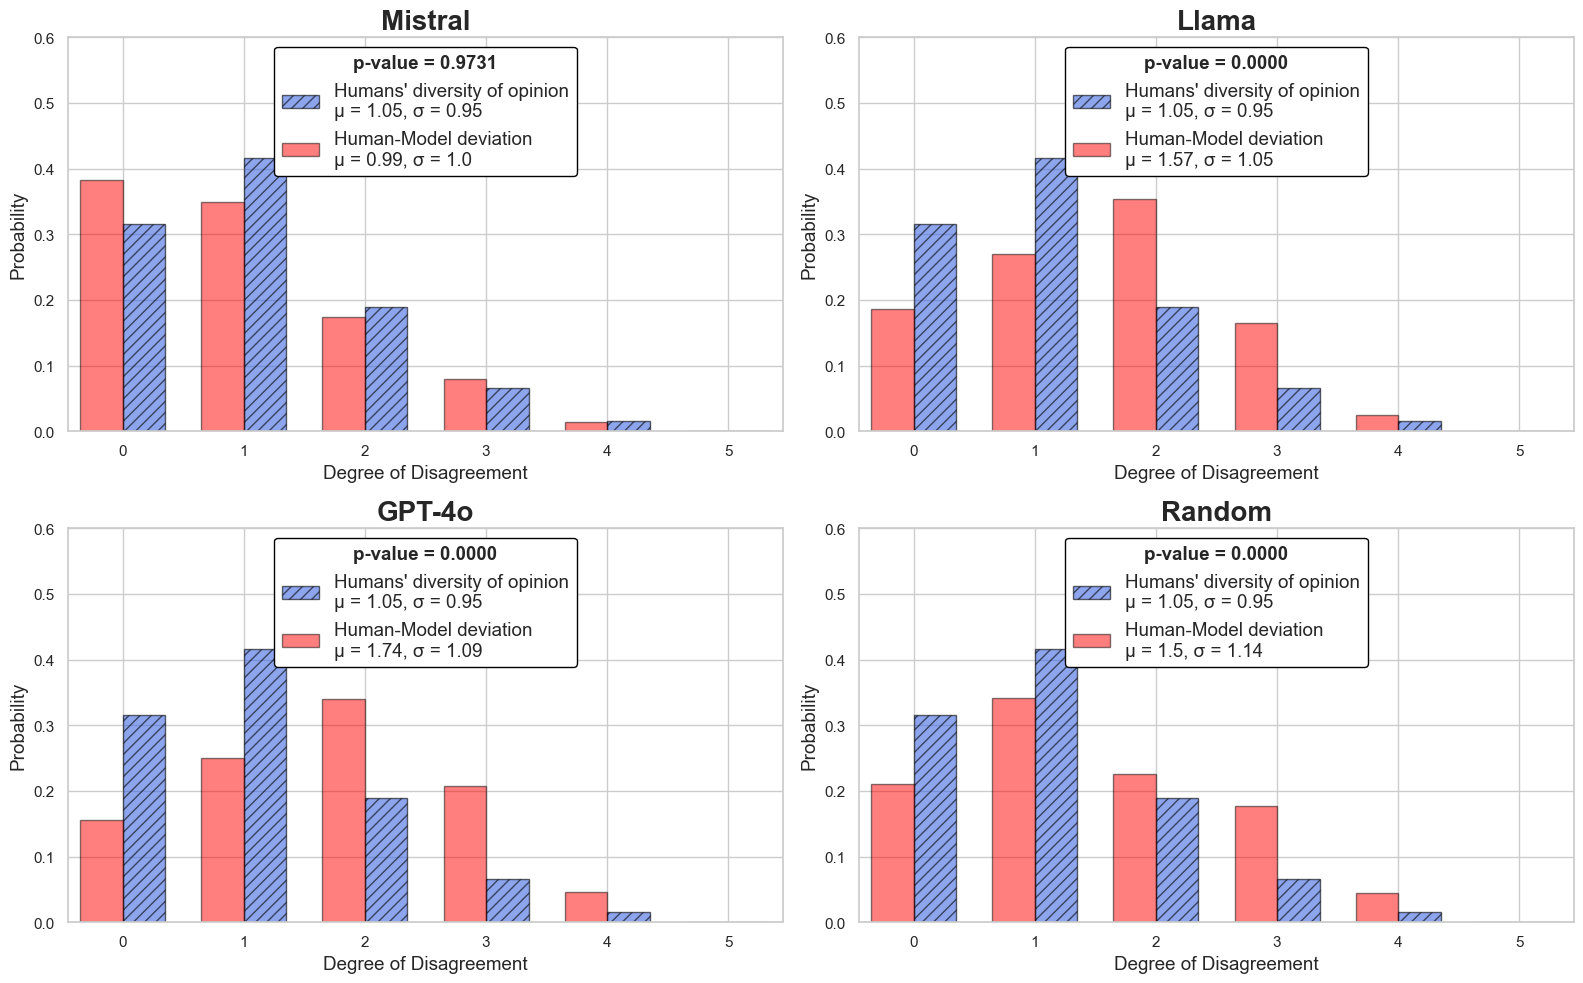

In [16]:
llm_human_disagreements_informativeness = {
    'Mistral': llm_human_disagreements['MISTRAL_informativeness'],
    'Llama': llm_human_disagreements['LLAMA_informativeness'],
    'GPT-4o': llm_human_disagreements['GPT_informativeness'],
    'Random': human_random_disagreements['random_informativeness']
}


Informativeness_LLM_Evaluator.plot_model_vs_human_grid(
    model_disagreement_dict=llm_human_disagreements_informativeness,
    human_human_disagreements=human_disagreements['informativeness'],
    bins=np.arange(0, 5 + 2),
    bar_width=0.35,
    y_lim=0.6,
    save_path="newsroom_informativeness.svg"
)

#### II) ***Relevance***

✅ Figure saved as SVG → newsroom_relevance.svg


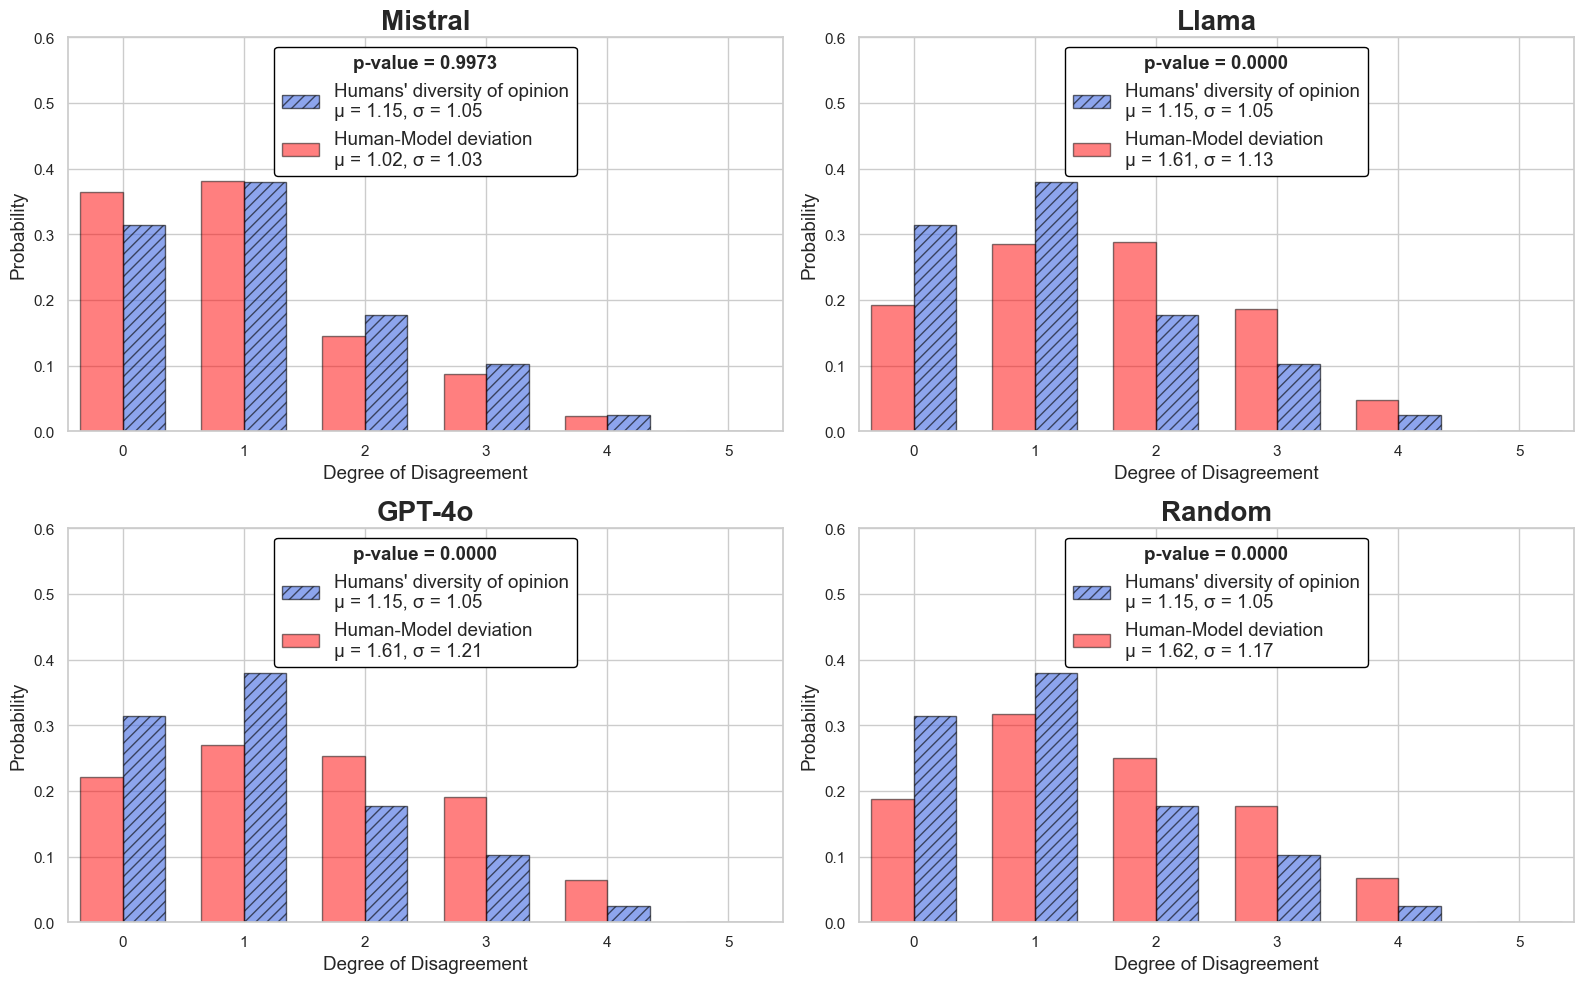

In [17]:
llm_human_disagreements_relevance = {
    'Mistral': llm_human_disagreements['MISTRAL_relevance'],
    'Llama': llm_human_disagreements['LLAMA_relevance'],
    'GPT-4o': llm_human_disagreements['GPT_relevance'],
    'Random': human_random_disagreements['random_relevance']
}


Relevance_LLM_Evaluator.plot_model_vs_human_grid(
    model_disagreement_dict=llm_human_disagreements_relevance,
    human_human_disagreements=human_disagreements['relevance'],
    bins=np.arange(0, 5 + 2),
    bar_width=0.35,
    y_lim=0.6,
    save_path="newsroom_relevance.svg"

)

#### III) ***Fluency***

✅ Figure saved as SVG → newsroom_fluency.svg


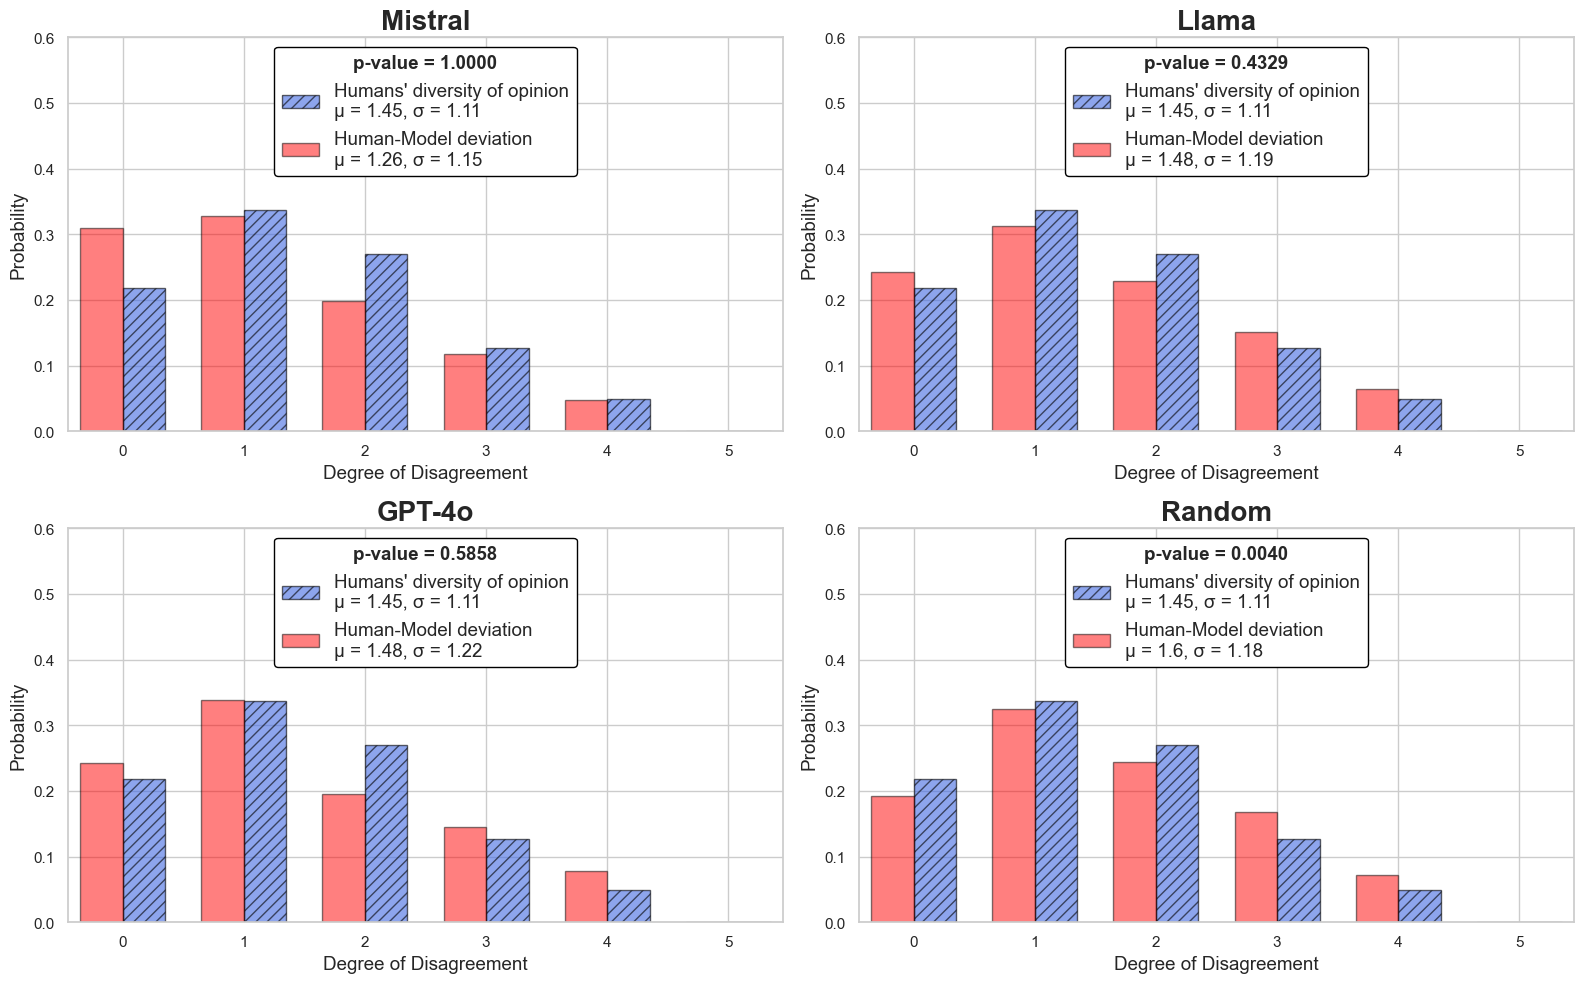

In [18]:
llm_human_disagreements_fluency = {
    'Mistral': llm_human_disagreements['MISTRAL_fluency'],
    'Llama': llm_human_disagreements['LLAMA_fluency'],
    'GPT-4o': llm_human_disagreements['GPT_fluency'],
    'Random': human_random_disagreements['random_fluency']
}


Fluency_LLM_Evaluator.plot_model_vs_human_grid(
    model_disagreement_dict=llm_human_disagreements_fluency,
    human_human_disagreements=human_disagreements['fluency'],
    bins=np.arange(0, 5 + 2),
    bar_width=0.35,
    y_lim=0.6,
    save_path="newsroom_fluency.svg"

)

#### ***`Tim's Interpretation of p-value`***
- paper

In [19]:
# save as vector grafik!

#### IV) ***Coherence***

✅ Figure saved as SVG → newsroom_coherence.svg


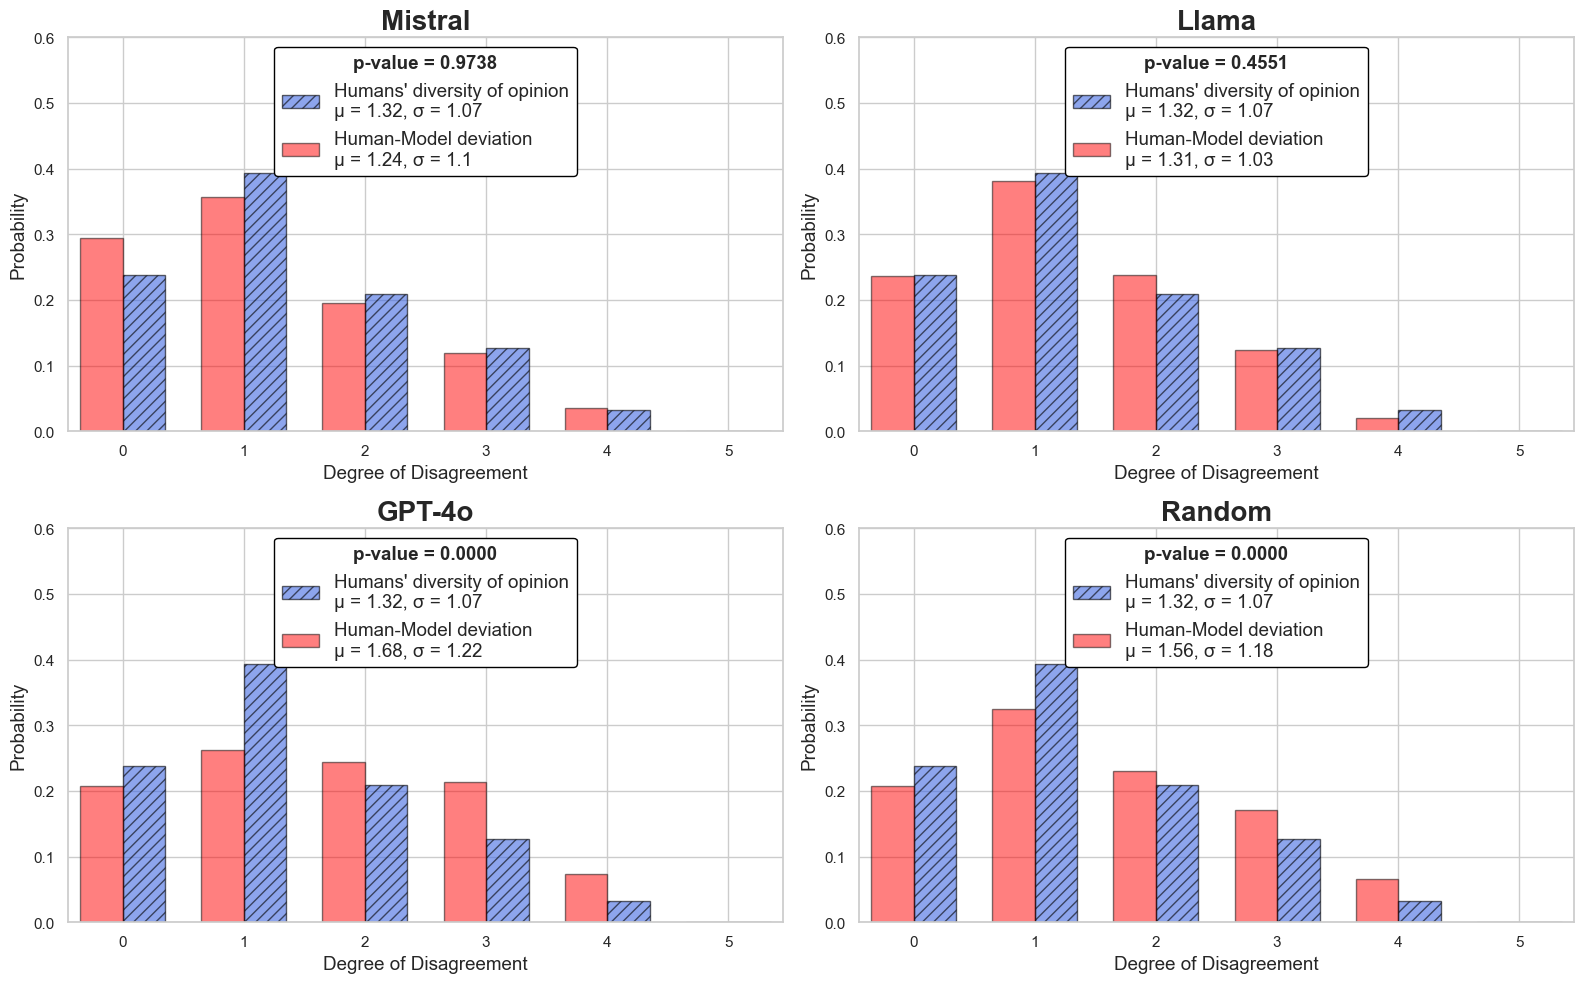

In [20]:
llm_human_disagreements_coherence = {
    'Mistral': llm_human_disagreements['MISTRAL_coherence'],
    'Llama': llm_human_disagreements['LLAMA_coherence'],
    'GPT-4o': llm_human_disagreements['GPT_coherence'],
    'Random': human_random_disagreements['random_coherence']
}


Coherence_LLM_Evaluator.plot_model_vs_human_grid(
    model_disagreement_dict=llm_human_disagreements_coherence,
    human_human_disagreements=human_disagreements['coherence'],
    bins=np.arange(0, 5 + 2),
    bar_width=0.35,
    y_lim=0.6,
    save_path="newsroom_coherence.svg"

)